# Report Figures Generation
Generate the visualizations required for Q2-Q4 in the report.

In [1]:
# === SETUP & GLOBAL CONFIGURATION ===
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Create output folder for figures
figures_dir = Path("../outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

# Set Seaborn whitegrid style
sns.set_theme(style="whitegrid")

# Professional font sizes and styling
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16
})

print("✅ Seaborn and Matplotlib styles configured successfully!")

✅ Seaborn and Matplotlib styles configured successfully!


## Figure 1: Baseline Retrieval Method Showdown

💾 Saved Figure 1 to ../outputs/figures/baseline_retrieval_showdown.png


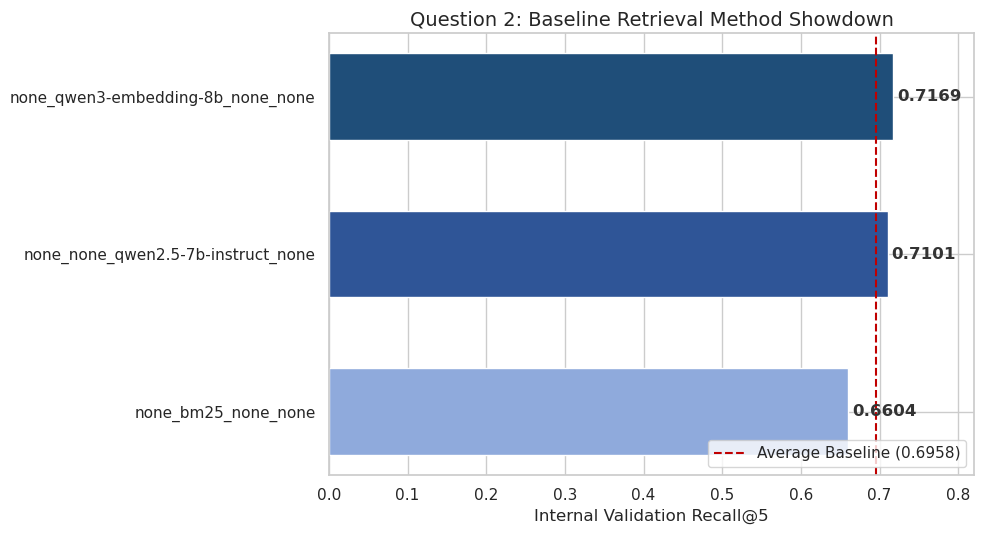

In [2]:
# === FIGURE 1: BASELINE RETRIEVAL SHOWDOWN ===
models = [
    'none_bm25_none_none',
    'none_none_qwen2.5-7b-instruct_none',
    'none_qwen3-embedding-8b_none_none'
]
scores = [0.6604, 0.7101, 0.7169]

# Sort bars in ascending order
sorted_indices = np.argsort(scores)
sorted_models = [models[i] for i in sorted_indices]
sorted_scores = [scores[i] for i in sorted_indices]

plt.figure(figsize=(10, 5.5))

# Deep corporate blue/gray palette
colors = ["#8faadc", "#2f5597", "#1f4e79"]
bars = plt.barh(sorted_models, sorted_scores, color=colors, height=0.55)

# Annotate exact value at the tip of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='left', fontweight='bold', color='#333333')

# Vertical red dashed line indicating average baseline benchmark
avg_score = np.mean(scores)
plt.axvline(avg_score, color='#c00000', linestyle='--', linewidth=1.5, 
            label=f'Average Baseline ({avg_score:.4f})')

plt.xlim(0, 0.82)
plt.xlabel("Internal Validation Recall@5")
plt.title("Question 2: Baseline Retrieval Method Showdown")
plt.legend(loc="lower right")
plt.tight_layout()

# Save figure
fig1_path = figures_dir / "baseline_retrieval_showdown.png"
plt.savefig(fig1_path, dpi=300)
print(f"💾 Saved Figure 1 to {fig1_path}")
plt.show()

## Figure 2: Hybrid Text Truncation Analysis

💾 Saved Figure 2 to ../outputs/figures/hybrid_text_truncation_analysis.png


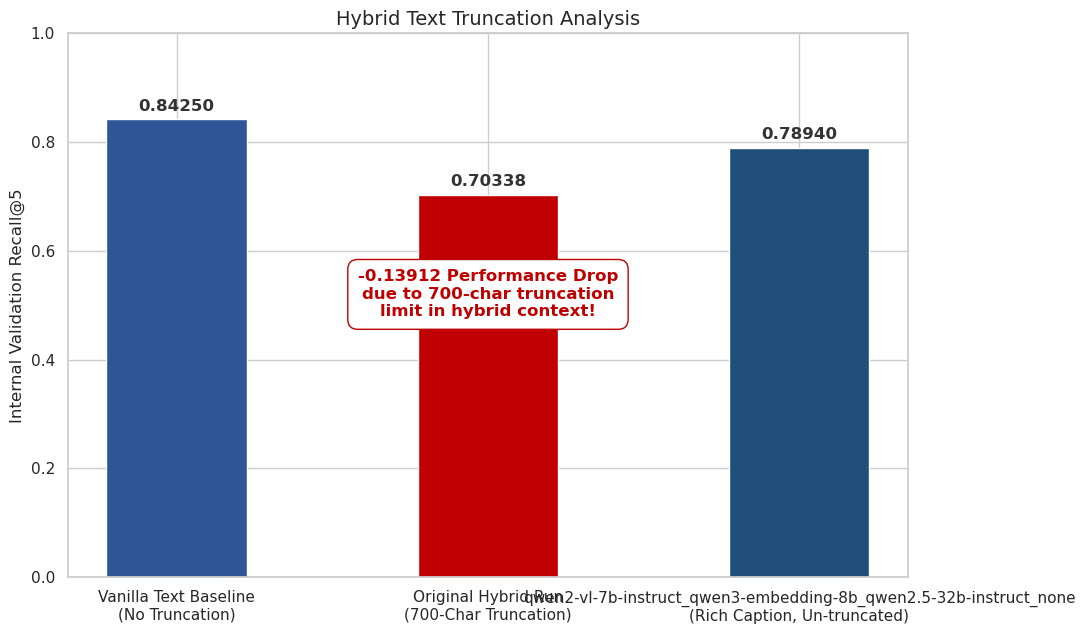

In [3]:
# === FIGURE 2: HYBRID TEXT TRUNCATION ANALYSIS ===
categories = [
    'Vanilla Text Baseline\n(No Truncation)',
    'Original Hybrid Run\n(700-Char Truncation)',
    'qwen2-vl-7b-instruct_qwen3-embedding-8b_qwen2.5-32b-instruct_none\n(Rich Caption, Un-truncated)'
]
scores = [0.8425, 0.70338, 0.7894]

# Use deep blue, alert red (to emphasize truncation drop), and dark primary corporate blue
colors = ["#2f5597", "#c00000", "#1f4e79"]

plt.figure(figsize=(11, 6.5))
bars = plt.bar(categories, scores, color=colors, width=0.45)

# Annotate exact value at the tip of each column
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.5f}', 
             va='bottom', ha='center', fontweight='bold', color='#333333')

plt.ylim(0, 1.0)
plt.ylabel("Internal Validation Recall@5")
plt.title("Hybrid Text Truncation Analysis")

# Highlight the drop visually with a text box
plt.text(1, 0.52, "-0.13912 Performance Drop\ndue to 700-char truncation\nlimit in hybrid context!", 
         ha='center', va='center', color='#c00000', weight='bold', 
         bbox=dict(facecolor='white', edgecolor='#c00000', boxstyle='round,pad=0.6'))

plt.tight_layout()

# Save figure
fig2_path = figures_dir / "hybrid_text_truncation_analysis.png"
plt.savefig(fig2_path, dpi=300)
print(f"💾 Saved Figure 2 to {fig2_path}")
plt.show()

## Figure 3: Multimodal Paradigm vs Text Translation

💾 Saved Figure 3 to ../outputs/figures/multimodal_vs_text_translation.png


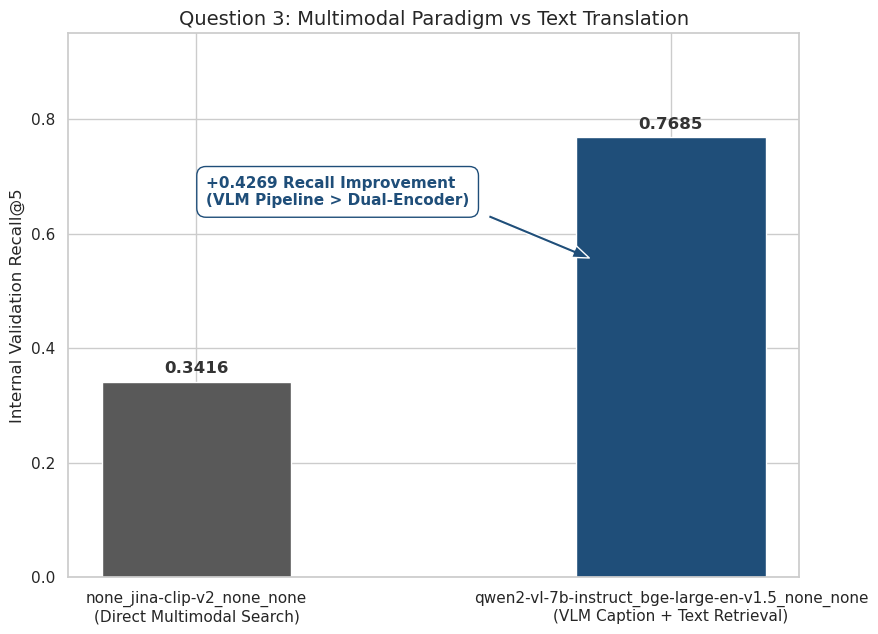

In [4]:
# === FIGURE 3: MULTIMODAL PARADIGM VS TEXT TRANSLATION ===
categories = [
    'none_jina-clip-v2_none_none\n(Direct Multimodal Search)',
    'qwen2-vl-7b-instruct_bge-large-en-v1.5_none_none\n(VLM Caption + Text Retrieval)'
]
scores = [0.3416, 0.7685]

plt.figure(figsize=(9, 6.5))

# Slate gray for baseline and professional corporate blue for the VLM approach
colors = ["#595959", "#1f4e79"]
bars = plt.bar(categories, scores, color=colors, width=0.4)

# Annotate exact value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', 
             va='bottom', ha='center', fontweight='bold', color='#333333')

plt.ylim(0, 0.95)
plt.ylabel("Internal Validation Recall@5")
plt.title("Question 3: Multimodal Paradigm vs Text Translation")

# Add arrow annotation highlighting the +0.4269 recall improvement
plt.annotate(
    '+0.4269 Recall Improvement\n(VLM Pipeline > Dual-Encoder)', 
    xy=(0.85, 0.55), 
    xytext=(0.02, 0.65),
    arrowprops=dict(facecolor='#1f4e79', shrink=0.08, width=2.5, headwidth=9),
    fontsize=11, 
    fontweight='bold', 
    color='#1f4e79',
    bbox=dict(facecolor='white', edgecolor='#1f4e79', boxstyle='round,pad=0.6')
)

plt.tight_layout()

# Save figure
fig3_path = figures_dir / "multimodal_vs_text_translation.png"
plt.savefig(fig3_path, dpi=300)
print(f"💾 Saved Figure 3 to {fig3_path}")
plt.show()